In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../Data/TrackDel_Cleaned.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Delay_Days
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class,-1
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class,1
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class,0
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class,-1
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class,-2


In [2]:
print("Missing Values:")
display(df.isnull().sum().sort_values(ascending=False).head(15))

print("\nData Types:")
display(df.dtypes)

Missing Values:


Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipping (real)              0
Days for shipment (scheduled)         0
Sales per customer                    0
Benefit per order                     0
Delivery Status                       0
Late_delivery_risk                    0
Customer City                         0
Customer Country                      0
Category Id                           0
Category Name                         0
Customer Fname                        0
Customer Email                        0
dtype: int64


Data Types:


Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Email                       str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Password                    str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        float64
Market          

In [4]:
# Basic Business KPIs

total_orders = len(df)
total_sales = df["Sales"].sum()
avg_order_value = df["Sales"].mean()

# Automatically find shipping-day column
shipping_col = next(
    (col for col in df.columns if "shipping" in col.lower() and "day" in col.lower()),
    None
)

print(f"Total Orders: {total_orders:,}")
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Average Order Value: ${avg_order_value:,.2f}")

if shipping_col:
    avg_shipping_days = df[shipping_col].mean()
    print(f"Average Shipping Days: {avg_shipping_days:.2f}")
else:
    print("Shipping-days column not found.")

Total Orders: 180,519
Total Sales: $36,784,735.01
Average Order Value: $203.77
Average Shipping Days: 3.50


In [5]:
# Market Performance Analysis

market_performance = (
    df.groupby("Market")
      .agg(
          Total_Orders=("Sales", "count"),
          Total_Revenue=("Sales", "sum"),
          Average_Order_Value=("Sales", "mean")
      )
      .sort_values("Total_Revenue", ascending=False)
)

market_performance

,Total_Orders,Total_Revenue,Average_Order_Value
Market,,,
Europe,50252,1.087240e+07,216.357494
LATAM,51594,1.027761e+07,199.201706
Pacific Asia,41260,8.273744e+06,200.526993
USCA,25799,5.066529e+06,196.384694
Africa,11614,2.294453e+06,197.559232


In [6]:
# Delivery Risk Analysis

delivery_risk = (
    df.groupby("Market")
      .agg(
          Total_Orders=("Late_delivery_risk", "count"),
          Late_Risk_Rate=("Late_delivery_risk", "mean")
      )
)

delivery_risk["Late_Risk_Rate"] = delivery_risk["Late_Risk_Rate"] * 100

delivery_risk.sort_values("Late_Risk_Rate", ascending=False)

,Total_Orders,Late_Risk_Rate
Market,,
Europe,50252,55.207753
Pacific Asia,41260,55.046049
USCA,25799,54.800574
Africa,11614,54.589289
LATAM,51594,54.355158


In [7]:
# Product Category Performance

category_performance = (
    df.groupby("Category_Name")
      .agg(
          Orders=("Sales", "count"),
          Revenue=("Sales", "sum"),
          Average_Sales=("Sales", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

category_performance.head(10)

KeyError: 'Category_Name'

In [8]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrders)', 'Shipping Mode', 

In [9]:
# Delivery Risk Analysis by Market

delivery_risk = (
    df.groupby("Market")
      .agg(
          Total_Orders=("Order Id", "count"),
          Late_Orders=("Late_delivery_risk", "sum")
      )
)

delivery_risk["Late_Risk_Rate"] = (
    delivery_risk["Late_Orders"] /
    delivery_risk["Total_Orders"] * 100
)

delivery_risk = delivery_risk.sort_values(
    "Late_Risk_Rate",
    ascending=False
)

display(delivery_risk)

,Total_Orders,Late_Orders,Late_Risk_Rate
Market,,,
Europe,50252,27743,55.207753
Pacific Asia,41260,22712,55.046049
USCA,25799,14138,54.800574
Africa,11614,6340,54.589289
LATAM,51594,28044,54.355158


In [10]:
# Shipping Mode Performance

shipping_analysis = (
    df.groupby("Shipping Mode")
      .agg(
          Orders=("Order Id", "count"),
          Revenue=("Sales", "sum"),
          Average_Order_Value=("Sales", "mean"),
          Average_Delay_Days=("Delay_Days", "mean"),
          Late_Risk=("Late_delivery_risk", "mean")
      )
)

shipping_analysis["Late_Risk"] *= 100

display(
    shipping_analysis.sort_values(
        "Revenue",
        ascending=False
    )
)

,Orders,Revenue,Average_Order_Value,Average_Delay_Days,Late_Risk
Shipping Mode,,,,,
Standard Class,107752,2.202239e+07,204.380354,-0.004093,38.071683
Second Class,35216,7.145445e+06,202.903363,1.990828,76.632781
First Class,27814,5.674370e+06,204.011281,1.000000,95.322499
Same Day,9737,1.942529e+06,199.499698,0.478279,45.743042


In [11]:
# Top 10 Product Categories by Revenue

category_performance = (
    df.groupby("Category Name")
      .agg(
          Orders=("Order Id", "count"),
          Revenue=("Sales", "sum"),
          Average_Sales=("Sales", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

display(category_performance.head(10))

,Orders,Revenue,Average_Sales
Category Name,,,
Fishing,17325,6.929654e+06,399.980011
Cleats,24551,4.431943e+06,180.519848
Camping & Hiking,13729,4.118426e+06,299.980011
Cardio Equipment,12487,3.694843e+06,295.895187
Women's Apparel,21035,3.147800e+06,149.645828
Water Sports,15540,3.113845e+06,200.376106
Men's Footwear,22246,2.891758e+06,129.990005
Indoor/Outdoor Games,19298,2.888994e+06,149.704317
Shop By Sport,10984,1.309522e+06,119.220870


In [12]:
# Customer Segment Performance

segment_performance = (
    df.groupby("Customer Segment")
      .agg(
          Orders=("Order Id", "count"),
          Revenue=("Sales", "sum"),
          Average_Order_Value=("Sales", "mean"),
          Average_Profit=("Order Profit Per Order", "mean")
      )
      .sort_values("Revenue", ascending=False)
)

display(segment_performance)

,Orders,Revenue,Average_Order_Value,Average_Profit
Customer Segment,,,,
Consumer,93504,1.909579e+07,204.224313,22.175390
Corporate,54789,1.116841e+07,203.843962,21.949204
Home Office,32226,6.520538e+06,202.337802,21.437359


In [13]:
# Top 10 Products by Revenue

top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

display(top_products)

Product Name
Field & Stream Sportsman 16 Gun Fire Safe        6.929654e+06
Perfect Fitness Perfect Rip Deck                 4.421143e+06
Diamondback Women's Serene Classic Comfort Bi    4.118426e+06
Nike Men's Free 5.0+ Running Shoe                3.667633e+06
Nike Men's Dri-FIT Victory Golf Polo             3.147800e+06
Pelican Sunstream 100 Kayak                      3.099845e+06
Nike Men's CJ Elite 2 TD Football Cleat          2.891758e+06
O'Brien Men's Neoprene Life Vest                 2.888994e+06
Under Armour Girls' Toddler Spine Surge Runni    1.269083e+06
Dell Laptop                                      6.630000e+05
Name: Sales, dtype: float64

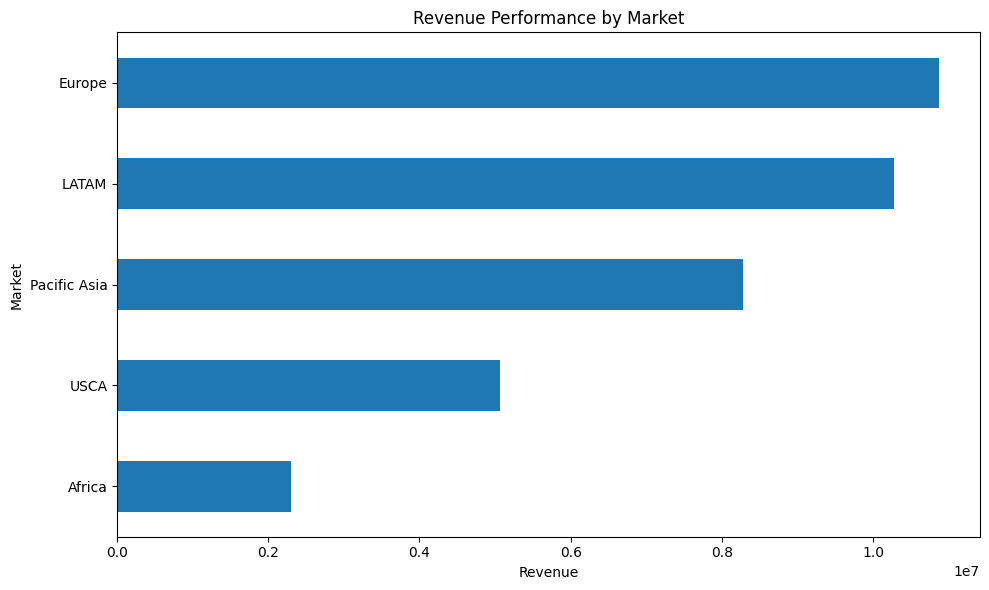

In [14]:
# Revenue by Market

market_performance["Total_Revenue"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Revenue Performance by Market")
plt.xlabel("Revenue")
plt.ylabel("Market")
plt.tight_layout()
plt.show()

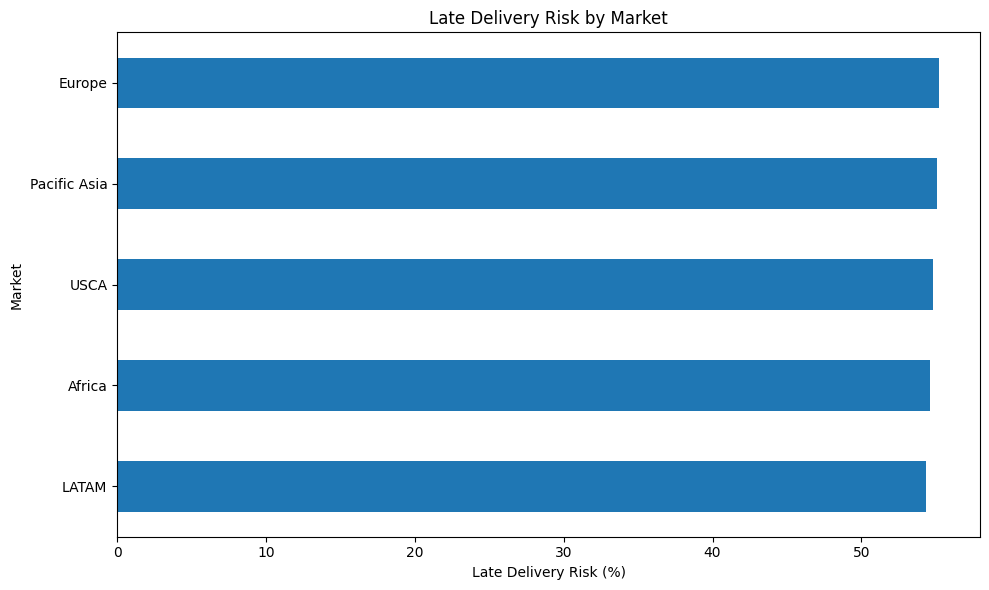

In [15]:
# Late Delivery Risk by Market

delivery_risk["Late_Risk_Rate"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Late Delivery Risk by Market")
plt.xlabel("Late Delivery Risk (%)")
plt.ylabel("Market")
plt.tight_layout()
plt.show()

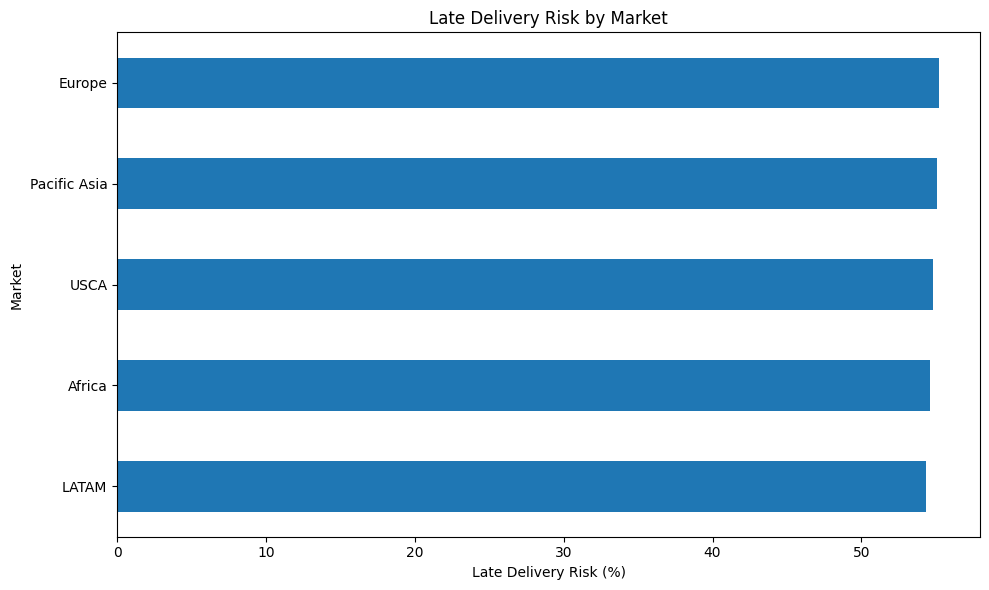

In [16]:
# Late Delivery Risk by Market

delivery_risk["Late_Risk_Rate"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Late Delivery Risk by Market")
plt.xlabel("Late Delivery Risk (%)")
plt.ylabel("Market")
plt.tight_layout()
plt.show()

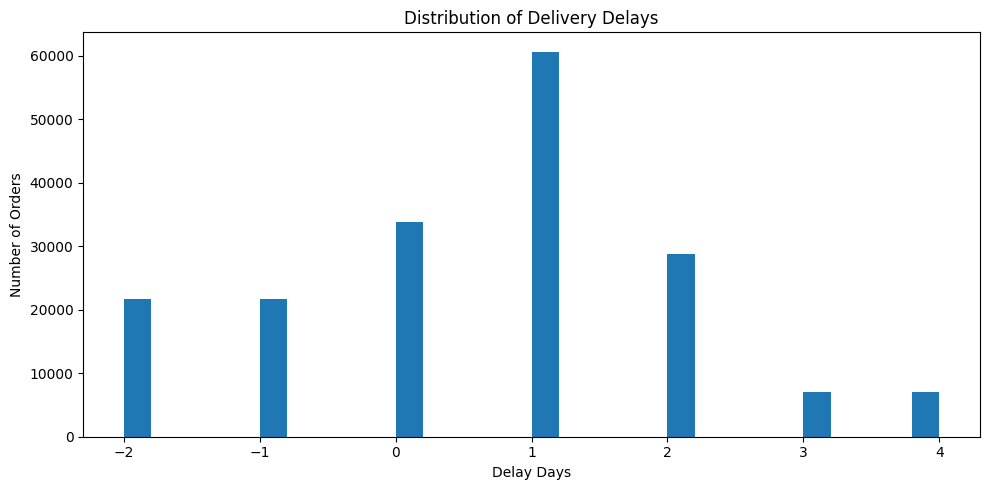

In [17]:
# Distribution of Delivery Delays

plt.figure(figsize=(10, 5))

plt.hist(
    df["Delay_Days"].dropna(),
    bins=30
)

plt.title("Distribution of Delivery Delays")
plt.xlabel("Delay Days")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.show()

In [18]:
# Correlation Analysis

numeric_columns = [
    "Sales",
    "Benefit per order",
    "Sales per customer",
    "Order Item Quantity",
    "Order Item Discount",
    "Order Item Profit Ratio",
    "Order Profit Per Order",
    "Product Price",
    "Delay_Days",
    "Late_delivery_risk"
]

correlation = df[numeric_columns].corr()

display(correlation.round(2))

,Sales,Benefit per order,Sales per customer,Order Item Quantity,Order Item Discount,Order Item Profit Ratio,Order Profit Per Order,Product Price,Delay_Days,Late_delivery_risk
Sales,1.00,0.13,0.99,0.11,0.62,-0.00,0.13,0.79,-0.00,-0.00
Benefit per order,0.13,1.00,0.13,0.02,0.06,0.82,1.00,0.10,-0.01,-0.00
Sales per customer,0.99,0.13,1.00,0.11,0.50,-0.00,0.13,0.78,-0.00,-0.00
Order Item Quantity,0.11,0.02,0.11,1.00,0.07,0.00,0.02,-0.48,0.00,-0.00
Order Item Discount,0.62,0.06,0.50,0.07,1.00,-0.00,0.06,0.49,-0.00,-0.00
Order Item Profit Ratio,-0.00,0.82,-0.00,0.00,-0.00,1.00,0.82,-0.00,-0.00,-0.00
Order Profit Per Order,0.13,1.00,0.13,0.02,0.06,0.82,1.00,0.10,-0.01,-0.00
Product Price,0.79,0.10,0.78,-0.48,0.49,-0.00,0.10,1.00,-0.00,-0.00
Delay_Days,-0.00,-0.01,-0.00,0.00,-0.00,-0.00,-0.01,-0.00,1.00,0.78
Late_delivery_risk,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.78,1.00


In [19]:
# Final Business Insights

best_market = market_performance["Total_Revenue"].idxmax()
best_segment = segment_performance["Revenue"].idxmax()
best_category = category_performance["Revenue"].idxmax()
highest_risk_market = delivery_risk["Late_Risk_Rate"].idxmax()
best_shipping_mode = shipping_analysis["Late_Risk"].idxmin()

print("=" * 60)
print("          TRACKDEL BUSINESS INSIGHTS")
print("=" * 60)

print(f"1. Highest revenue market       : {best_market}")
print(f"2. Highest revenue segment      : {best_segment}")
print(f"3. Top product category         : {best_category}")
print(f"4. Highest delivery-risk market : {highest_risk_market}")
print(f"5. Lowest-risk shipping mode    : {best_shipping_mode}")

print("=" * 60)

          TRACKDEL BUSINESS INSIGHTS
1. Highest revenue market       : Europe
2. Highest revenue segment      : Consumer
3. Top product category         : Fishing
4. Highest delivery-risk market : Europe
5. Lowest-risk shipping mode    : Standard Class


In [20]:
# Executive Summary

print("""
EXECUTIVE SUMMARY
-----------------

The analysis evaluates supply-chain performance across markets,
customer segments, product categories and shipping modes.

The analysis focuses on:
• Revenue performance
• Customer purchasing behavior
• Product/category contribution
• Shipping efficiency
• Delivery delays
• Late-delivery risk
• Operational performance

These insights can help management identify high-performing
markets, improve logistics efficiency and reduce delivery risk.
""")


EXECUTIVE SUMMARY
-----------------

The analysis evaluates supply-chain performance across markets,
customer segments, product categories and shipping modes.

The analysis focuses on:
• Revenue performance
• Customer purchasing behavior
• Product/category contribution
• Shipping efficiency
• Delivery delays
• Late-delivery risk
• Operational performance

These insights can help management identify high-performing
markets, improve logistics efficiency and reduce delivery risk.

